In [3]:
import pandas as pd
import yfinance as yf
import requests
import io # 文字列をファイルのように扱うためのライブラリ

print("S&P500の銘柄リストを取得中...")
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}
response = requests.get(url, headers=headers)
tables = pd.read_html(io.StringIO(response.text))
sp500_df = tables[0]

# 2. ティッカーシンボルの整形
tickers = sp500_df['Symbol'].str.replace('.', '-', regex=False).tolist()

print(f"取得完了: {len(tickers)} 銘柄が見つかりました。")
print(f"例: {tickers[:5]}")

# 3. データ取得
target_tickers = tickers[:30]

print(f"\n{len(target_tickers)} 銘柄の株価データをダウンロード中...")
data = yf.download(
    target_tickers,
    start="2019-01-01",
    end="2026-01-01",
    auto_adjust=True
)

# yfinanceのバージョンによって戻り値の形式が違うため、
if 'Close' in data.columns.levels[0]:
    data = data['Close']
elif 'Close' in data.columns:
    data = data['Close']

# 4. データの確認と保存
print("\nデータの取得に成功しました。中身を確認します:")
display(data.head())

# CSVに保存
data.to_csv('sp500_stock_prices.csv')
print("\n'sp500_stock_prices.csv' に保存しました。")

S&P500の銘柄リストを取得中...
取得完了: 503 銘柄が見つかりました。
例: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN']

30 銘柄の株価データをダウンロード中...


[*********************100%***********************]  30 of 30 completed


データの取得に成功しました。中身を確認します:


Ticker,A,ABBV,ABNB,ABT,ACN,ADBE,AEE,AEP,AES,AFL,...,AOS,APD,ARE,AWK,AXP,GOOG,GOOGL,LNT,MMM,MO
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,62.442295,65.326935,NaN,61.182655,127.187775,224.570007,52.125607,56.979656,11.039043,38.615116,...,38.201294,135.027100,85.896317,77.831879,86.900307,51.903217,52.338547,33.023048,123.850967,28.626408
2019-01-03,60.141926,63.174515,NaN,58.295193,122.845360,215.699997,52.256886,56.846840,11.031256,37.639565,...,37.278572,131.405853,86.605888,78.138771,85.204063,50.424809,50.888996,33.079224,119.187546,28.469664
2019-01-04,62.223663,65.209808,NaN,59.959000,127.622002,226.190002,52.995308,57.370239,11.397149,38.106121,...,38.772518,136.736221,87.492851,78.726219,89.043396,53.136963,53.499271,33.480465,124.090988,29.201141
2019-01-07,63.544949,66.161560,NaN,60.856941,128.065308,229.259995,52.388157,57.049938,11.451642,38.309727,...,39.466774,135.314758,88.032745,77.893257,89.526764,53.021828,53.392578,33.247742,123.805626,28.318722
2019-01-08,64.476486,66.469032,NaN,60.126274,131.304031,232.679993,53.216854,57.753017,11.716331,38.428486,...,40.433445,133.757996,90.076607,79.033081,89.964500,53.413387,53.861534,33.761341,124.324509,28.481270



'sp500_stock_prices.csv' に保存しました。


In [8]:
import pandas as pd
import yfinance as yf
import time
from tqdm import tqdm

# （CSVの列名＝ティッカーになっています）
price_df = pd.read_csv('sp500_stock_prices.csv', index_col=0)
tickers = price_df.columns.tolist()

print(f"ティッカーリスト読み込み完了: 全{len(tickers)}銘柄")

# 2. 財務データを格納するリスト
fundamentals = []

# 本番（全銘柄）でやる時は、下の行を「for ticker in tickers:」に変えてください
target_tickers = tickers[:30]

print(f"\n{len(target_tickers)} 銘柄の財務データを取得開始...")

for ticker in tqdm(target_tickers):
    try:
        # yfinanceで詳細情報を取得
        t = yf.Ticker(ticker)
        info = t.info

        # .get()を使うと、データが無い場合もエラーにならずNoneを返してくれます
        data = {
            'Symbol': ticker,
            'Name': info.get('shortName'),
            'Sector': info.get('sector'),
            'Price': info.get('currentPrice'),
            'MarketCap': info.get('marketCap'),
            'DividendYield': info.get('dividendYield'), # 配当利回り
            'PayoutRatio': info.get('payoutRatio'),     # 配当性向
            'Beta': info.get('beta'),                   # ベータ値
            'ForwardPE': info.get('forwardPE'),         # 予想PER
            'FreeCashflow': info.get('freeCashflow'),   # フリーキャッシュフロー
            'OperatingMargins': info.get('operatingMargins') # 営業利益率
        }

        fundamentals.append(data)


        time.sleep(0.5)

    except Exception as e:
        print(f"Error ({ticker}): {e}")

# 3. データフレームに変換して保存
fund_df = pd.DataFrame(fundamentals)

# 見やすいように、利回り順（降順）に並べ替えて表示してみる
if 'DividendYield' in fund_df.columns:
    display_df = fund_df.sort_values('DividendYield', ascending=False)
else:
    display_df = fund_df

print("\nデータの取得完了。上位5銘柄を表示します:")
display(display_df.head())

# CSVに保存
fund_df.to_csv('sp500_fundamentals.csv', index=False)
print("\n'sp500_fundamentals.csv' に保存しました。")

ティッカーリスト読み込み完了: 全30銘柄

30 銘柄の財務データを取得開始...


100%|██████████| 30/30 [00:34<00:00,  1.15s/it]


データの取得完了。上位5銘柄を表示します:


,Symbol,Name,Sector,Price,MarketCap,DividendYield,PayoutRatio,Beta,ForwardPE,FreeCashflow,OperatingMargins
22,ARE,Alexandria Real Estate Equities,Real Estate,58.14,9925721088,8.05,6.8947,1.319,-726.750000,1.345211e+09,0.22740
29,MO,"Altria Group, Inc.",Consumer Defensive,63.62,106874658816,6.66,0.7863,0.501,11.380773,7.409125e+09,0.62826
16,AMCR,Amcor plc,Consumer Cyclical,44.72,20645971968,5.81,1.6944,0.676,10.057145,4.131250e+08,0.09713
8,AES,The AES Corporation,Utilities,14.92,10624844800,4.72,0.4608,0.969,6.452924,-3.689875e+09,0.20501
18,AMT,American Tower Corporation (REI,Real Estate,180.07,84318003200,3.78,1.0718,0.929,25.952484,4.248438e+09,0.45477



'sp500_fundamentals.csv' に保存しました。


In [11]:
import pandas as pd
import numpy as np

# 1. データの読み込み
df = pd.read_csv('sp500_fundamentals.csv')

print(f"分析開始: 全 {len(df)} 銘柄")

# --- Phase 1: 足切りフィルター (Screening) ---
# 条件:
# 1. 配当利回り (DividendYield) >= 3.0% (0.03)
# 2. 配当性向 (PayoutRatio) <= 80% (0.8) または 空欄でない
# 3. 営業利益率 (OperatingMargins) > 0 (黒字であること)

# ※データが欠損している(NaN)場合は除外されないように .fillna でケアします
df_screened = df[
    (df['DividendYield'] >= 3.00) &
    (df['PayoutRatio'] <= 0.8) &
    (df['OperatingMargins'] > 0)
].copy()

print(f"スクリーニング結果: {len(df_screened)} 銘柄が残りました。")

# --- Phase 2: オリジナル・スコアリング (Scoring) ---
# 各指標を「偏差値（0~100）」のように正規化して、総合点をつけます

def calculate_score(sub_df):
    res = sub_df.copy()

    # 評価項目1: フリーキャッシュフロー (金額そのものだと大小差がありすぎるので、対時価総額比率にするのがプロの技ですが、今回は簡易的に営業利益率を使います)
    # 営業利益率が高いほど高得点
    res['Score_Margin'] = res['OperatingMargins'].rank(pct=True) * 100

    # 評価項目2: ベータ値 (低いほど安全＝高得点)
    # 1から引くことで「低いほうが偉い」にする
    res['Score_Safety'] = (1 - res['Beta'].rank(pct=True)) * 100

    # 総合スコア: 利益率(60%) + 安全性(40%) の重み付け
    res['Total_Score'] = (res['Score_Margin'] * 0.6) + (res['Score_Safety'] * 0.4)

    return res

# スコア計算実行
# もしスクリーニングで全滅していたらエラーになるので分岐
if len(df_screened) > 0:
    df_scored = calculate_score(df_screened)

    # スコア順に並べ替え
    df_ranking = df_scored.sort_values('Total_Score', ascending=False)

    # 見やすい列だけ選んで表示
    cols = ['Symbol', 'Name', 'DividendYield', 'PayoutRatio', 'OperatingMargins', 'Beta', 'Total_Score']

    print("\n【優良高配当株ランキング Top 5】")
    display(df_ranking[cols].head())

    # 結果を保存
    df_ranking.to_csv('my_dividend_ranking.csv', index=False)
    print("\n'my_dividend_ranking.csv' に保存しました。")

else:
    print("\n条件に合う銘柄がありませんでした。フィルター条件を緩めてください。")

分析開始: 全 30 銘柄
スクリーニング結果: 4 銘柄が残りました。

【優良高配当株ランキング Top 5】


,Symbol,Name,DividendYield,PayoutRatio,OperatingMargins,Beta,Total_Score
29,MO,"Altria Group, Inc.",6.66,0.7863,0.62826,0.501,90.0
27,LNT,Alliant Energy Corporation,3.06,0.6297,0.28843,0.671,55.0
7,AEP,American Electric Power Company,3.18,0.5447,0.25885,0.615,50.0
8,AES,The AES Corporation,4.72,0.4608,0.20501,0.969,15.0



'my_dividend_ranking.csv' に保存しました。


比較対象: ['MO', 'LNT', 'AEP'] vs S&P500


[*********************100%***********************]  4 of 4 completed


グラフを 'performance_chart.png' に保存しました。


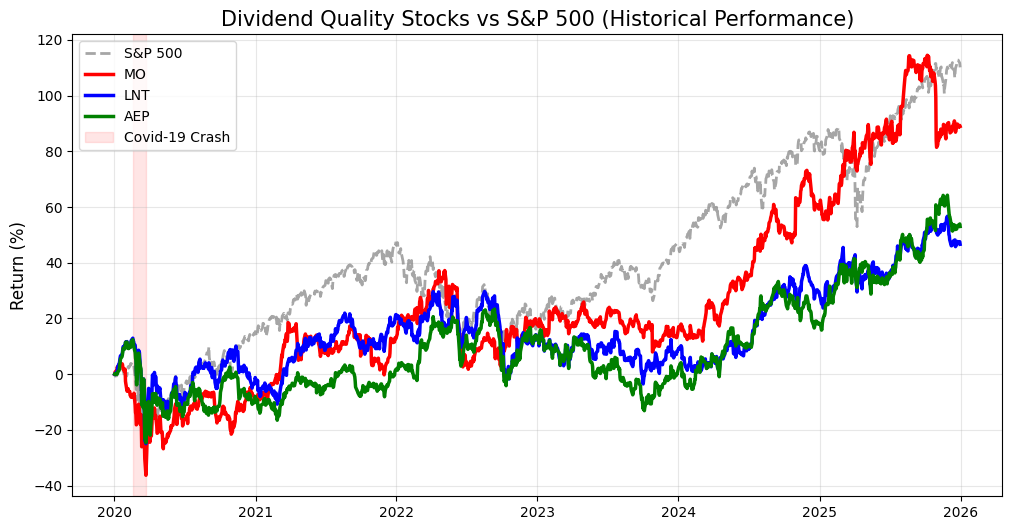

In [12]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 1. ランキング上位の銘柄を取得
df_ranking = pd.read_csv('my_dividend_ranking.csv')
top_tickers = df_ranking['Symbol'].head(3).tolist()
bench_ticker = '^GSPC'

print(f"比較対象: {top_tickers} vs S&P500")

# 2. 過去5年の株価データを取得
tickers_to_fetch = top_tickers + [bench_ticker]
data = yf.download(tickers_to_fetch, start="2020-01-01", end="2026-01-01", auto_adjust=True)

# データ形式の調整
if 'Close' in data.columns.levels[0]:
    data = data['Close']
elif 'Close' in data.columns:
    data = data['Close']

# 3. 「リターン（騰落率）」に変換する
# 株価そのままだと2000ドルと50ドルで比較できないので、「スタートを0%とした変化率」に直します
normalized_data = (data / data.iloc[0]) * 100 - 100

# 4. グラフ描画
plt.figure(figsize=(12, 6))

# ベンチマーク（S&P500）をグレーで描画（脇役）
plt.plot(normalized_data.index, normalized_data[bench_ticker],
         label='S&P 500', color='gray', linestyle='--', alpha=0.7, linewidth=2)

# Top銘柄をカラフルに描画
colors = ['red', 'blue', 'green']
for i, ticker in enumerate(top_tickers):
    plt.plot(normalized_data.index, normalized_data[ticker],
             label=ticker, color=colors[i], linewidth=2.5)

# 暴落期間（コロナショック）をハイライト
# 2020年2月〜3月を赤く塗る
plt.axvspan('2020-02-19', '2020-03-23', color='red', alpha=0.1, label='Covid-19 Crash')

# グラフの装飾
plt.title('Dividend Quality Stocks vs S&P 500 (Historical Performance)', fontsize=15)
plt.ylabel('Return (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')

# 保存
plt.savefig('performance_chart.png')
print("グラフを 'performance_chart.png' に保存しました。")
plt.show()